# Environment Setup

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import shap
import streamlit
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc
)

### Load Data

In [2]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df.sample(2)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
170193,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,0.0,10.0,0.0,1.0,12.0,5.0,7.0
75541,0.0,1.0,0.0,1.0,36.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,30.0,1.0,0.0,0.0,6.0,5.0,7.0


In [3]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df = df.rename(columns={'Diabetes_012':'Diabetes'})
df.sample()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
249304,0.0,0.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,1.0,0.0,0.0,0.0,9.0,4.0,8.0


### EDA

### Each column unique value counts

In [6]:
def unq_val_pct (df):
    for col in df:
        print(df[col].value_counts().sort_index(ascending=True)/sum(df[col].value_counts())*100)
        
unq_val_pct(df)

Diabetes
0.0    84.241170
1.0     1.825528
2.0    13.933302
Name: count, dtype: float64
HighBP
0.0    57.09989
1.0    42.90011
Name: count, dtype: float64
HighChol
0.0    57.587906
1.0    42.412094
Name: count, dtype: float64
CholCheck
0.0     3.73305
1.0    96.26695
Name: count, dtype: float64
BMI
12.0    0.002365
13.0    0.008278
14.0    0.016162
15.0    0.052034
16.0    0.137181
          ...   
91.0    0.000394
92.0    0.012614
95.0    0.004730
96.0    0.000394
98.0    0.002759
Name: count, Length: 84, dtype: float64
Smoker
0.0    55.683144
1.0    44.316856
Name: count, dtype: float64
Stroke
0.0    95.94292
1.0     4.05708
Name: count, dtype: float64
HeartDiseaseorAttack
0.0    90.581441
1.0     9.418559
Name: count, dtype: float64
PhysActivity
0.0    24.345632
1.0    75.654368
Name: count, dtype: float64
Fruits
0.0    36.574424
1.0    63.425576
Name: count, dtype: float64
Veggies
0.0    18.85801
1.0    81.14199
Name: count, dtype: float64
HvyAlcoholConsump
0.0    94.380322
1.0    

#### Check for Null

In [7]:
df.isnull().sum()

Diabetes                0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

#### Visualising Each Category

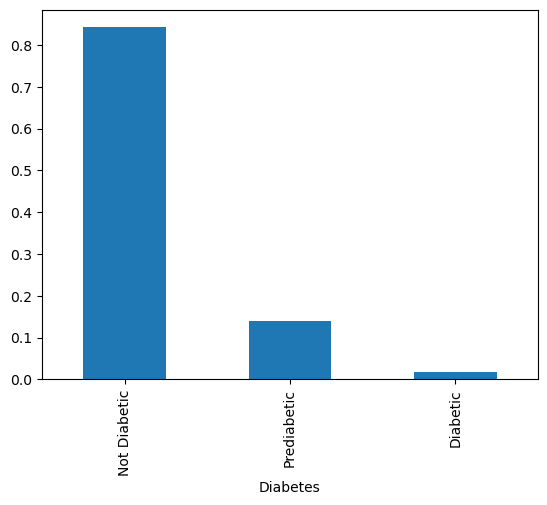

In [8]:
# Plotting diabetes
df['Diabetes'].value_counts(normalize = True).plot(kind='bar').set_xticklabels(['Not Diabetic','Prediabetic','Diabetic'])
fig_size=(6,5)
plt.show()

In [9]:
# Plotting diabetes
df['Diabetes'].value_counts(normalize = True).to_frame().style.bar()

,proportion
Diabetes,
0.000000,0.842412
2.000000,0.139333
1.000000,0.018255


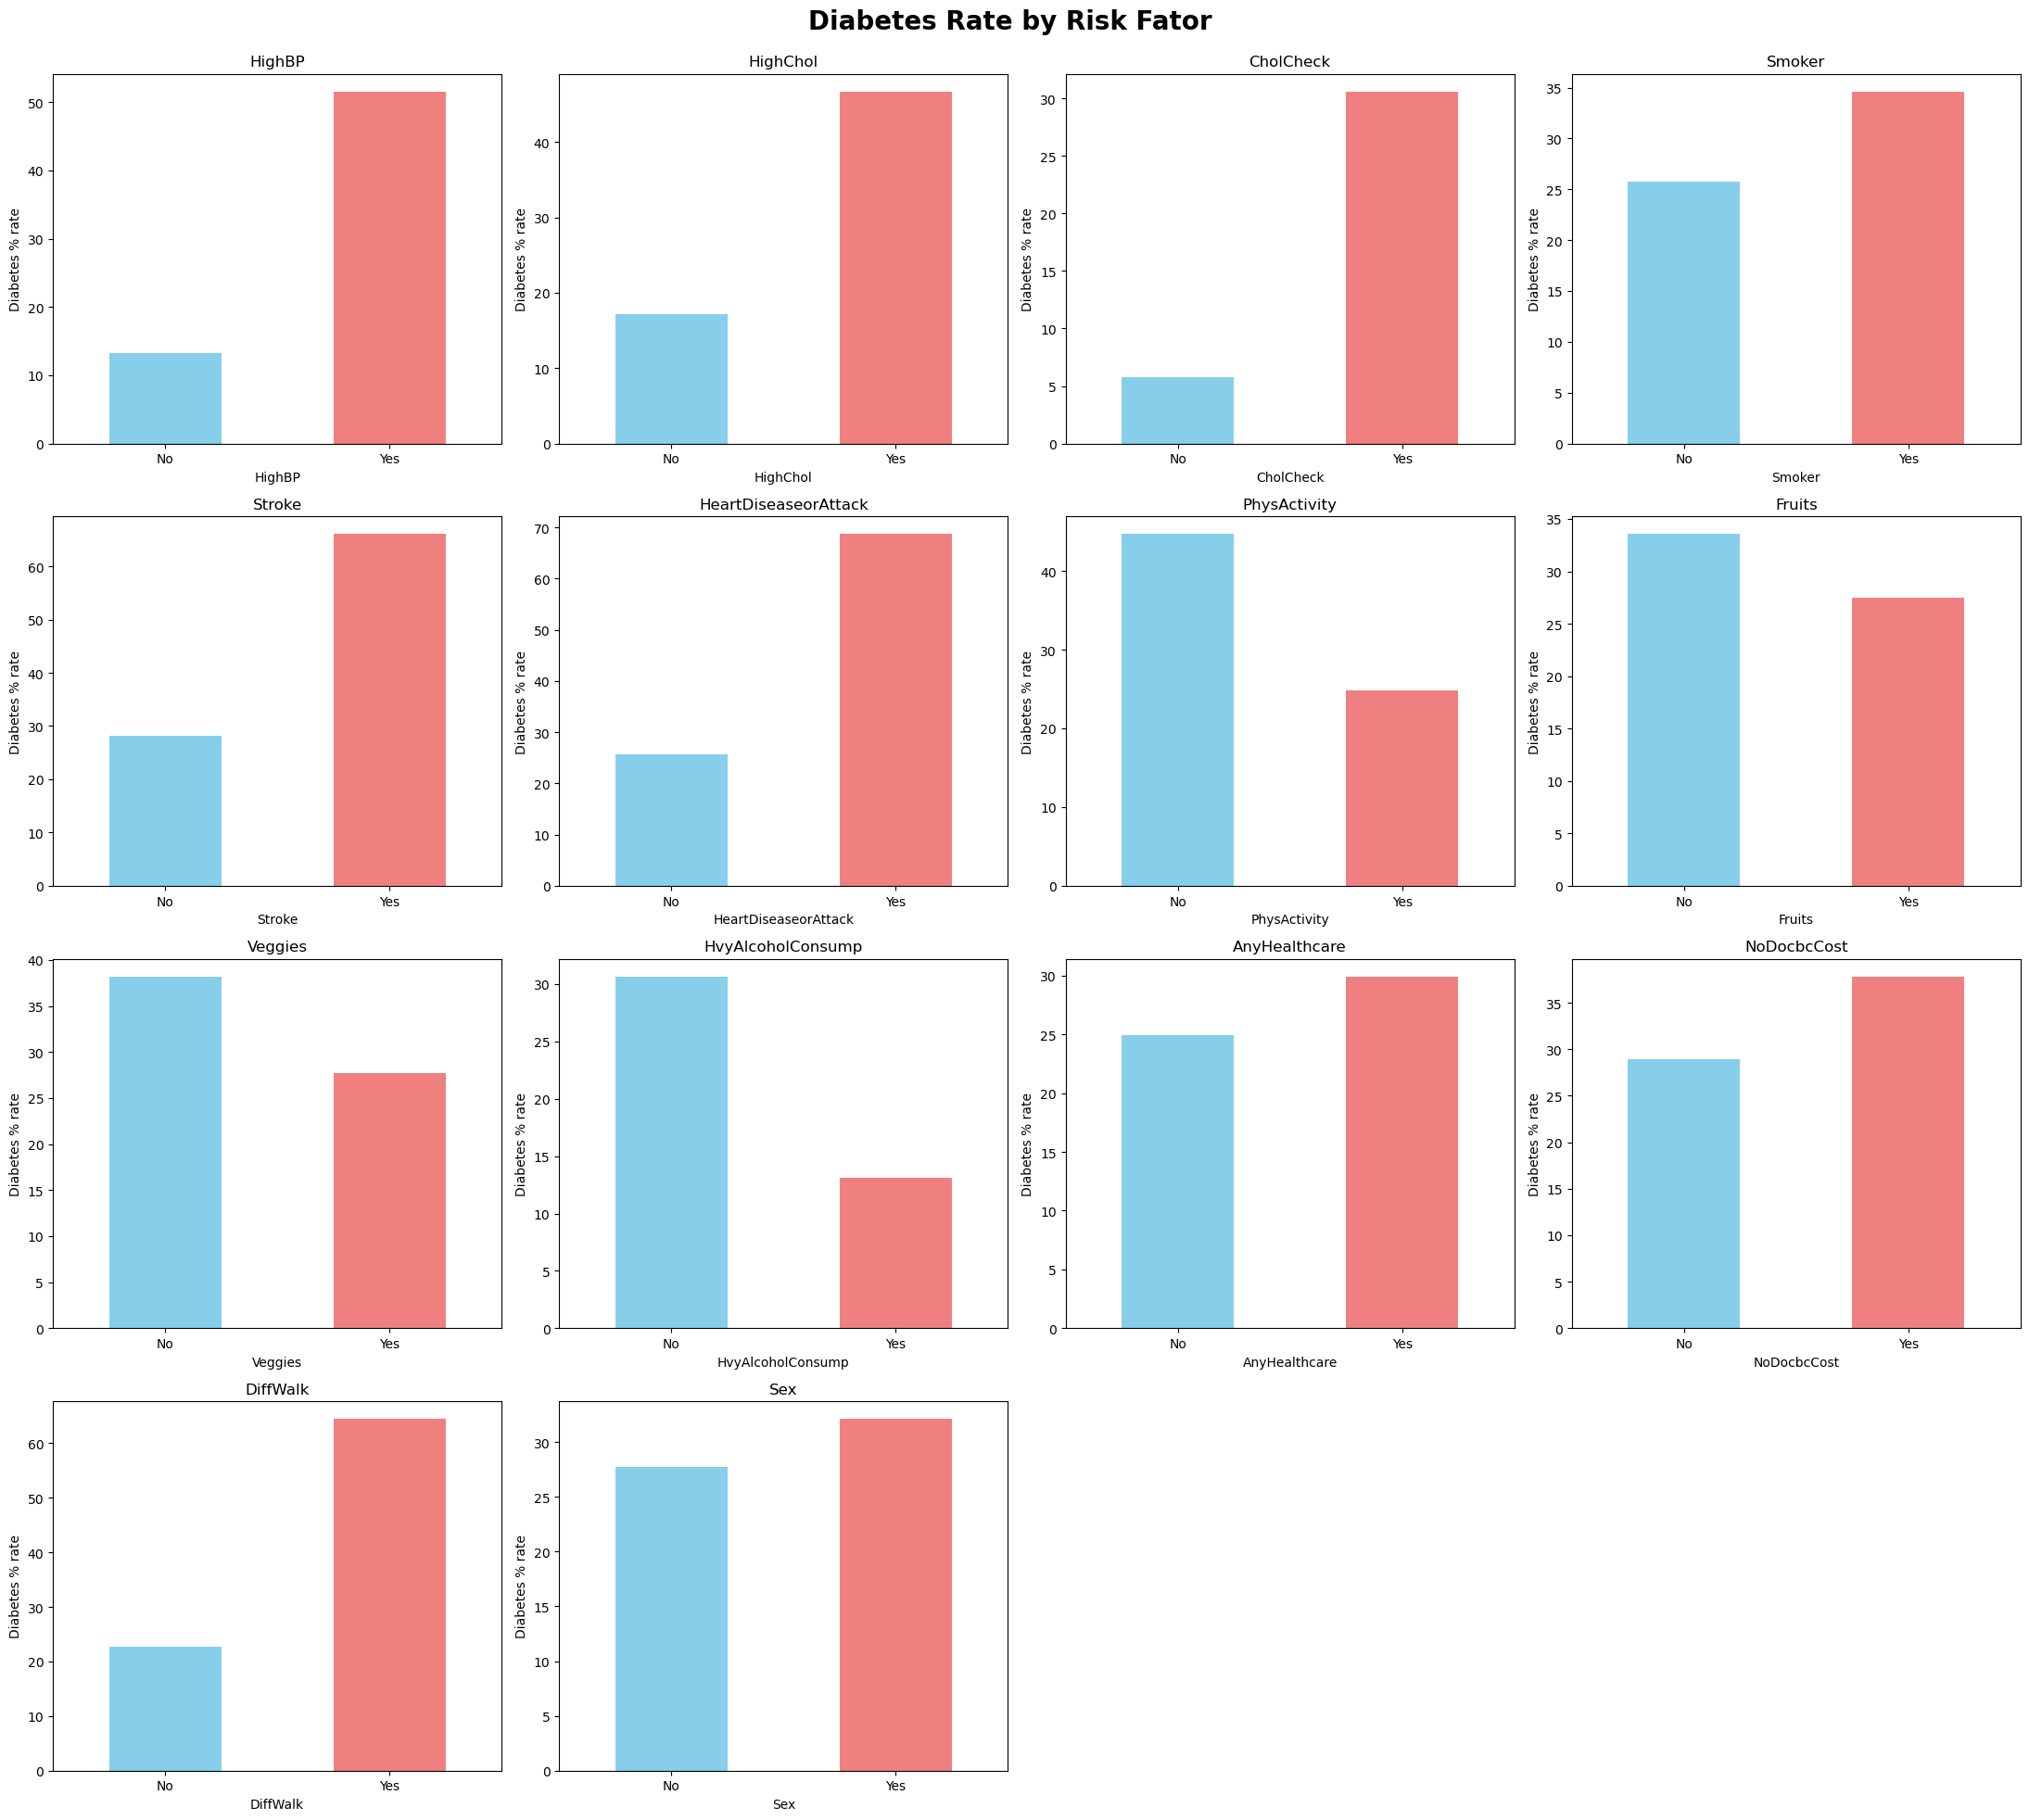

In [10]:
# Plotting Binary Features
counts = df.nunique()
binary_features=list(counts[counts==2].index)
n_features = len(binary_features)
n_cols=4
n_rows = (n_features + n_cols -1) // n_cols

fig,axes = plt.subplots(n_rows,n_cols,figsize=(22,n_rows*5))

axes_flat = axes.flatten()

for i,feature in enumerate(binary_features):
    ax=axes[i//4,i%4]
    rates = df.groupby(feature)['Diabetes'].mean()*100
    rates.plot(kind='bar',ax=ax,color=['skyblue','lightcoral'])
    ax.set_title(f'{feature}')
    ax.set_ylabel('Diabetes % rate')
    ax.set_xticklabels(['No','Yes'],rotation=0)
for j in range(i + 1,len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle(f'Diabetes Rate by Risk Fator \n',fontsize=20,fontweight='bold')
#axes[1,3].axis('off')
plt.tight_layout()
plt.show()

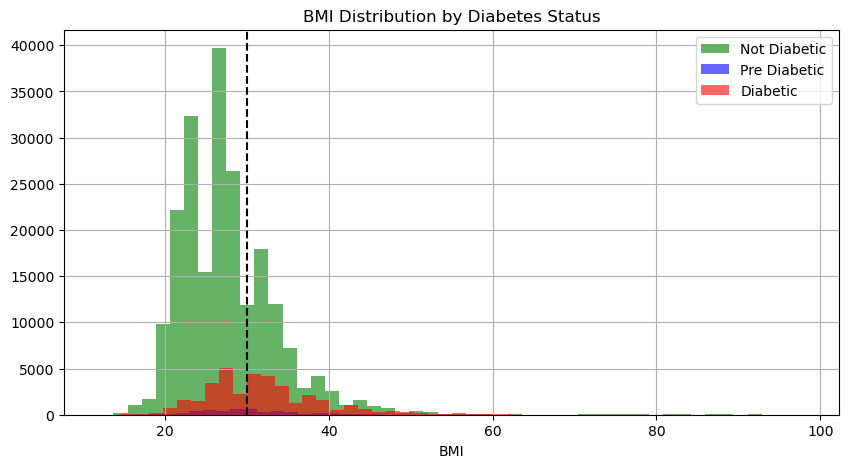

In [11]:
# BMI Distribution
fig,ax = plt.subplots(figsize=(10,5))
for label,color,name in [(0,'green','Not Diabetic'),(1,'blue','Pre Diabetic'),(2,'red','Diabetic')]:
    df[df['Diabetes']==label]['BMI'].hist(bins=50,alpha=0.6,color=color,label=name,ax=ax)

ax.set_title('BMI Distribution by Diabetes Status')
ax.set_xlabel('BMI')
ax.legend()
ax.axvline(x=30,color='black',linestyle='--',label='Obesity threshold')
plt.show()

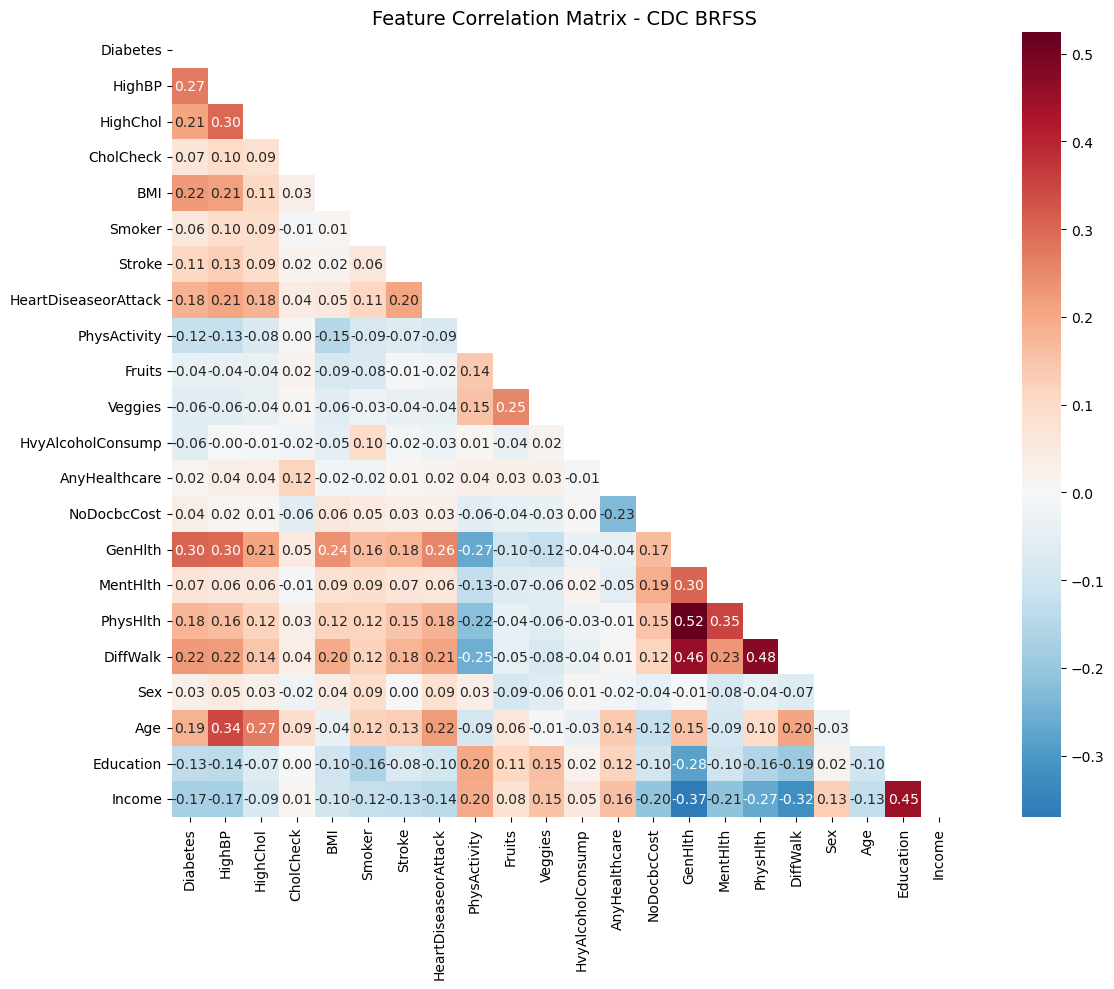

In [12]:
# Feature Correlation Matrix
plt.figure(figsize=(14,10))
corr=df.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,cmap='RdBu_r',center=0,square=True,fmt='.2f',annot=True)
plt.title('Feature Correlation Matrix - CDC BRFSS',fontsize=14)
plt.tight_layout()

## Loading the Data, Creating extra features , Extracting X,y

In [13]:
def load_data(data):
    df=data
    df= df.rename(columns={'Diabetes_012':'Diabetes'})
    # Creating additional features
    df['BP_Chol_Risk'] = df['HighBP'] + df['HighChol']
    df['Cardio_Risk'] = df['HighBP'] + df['HighChol'] + df['Stroke'] + df['HeartDiseaseorAttack']
    df['LifeStyle_Score'] = df['PhysActivity'] + df['Fruits'] + df['Veggies'] - df['Smoker'] - df['HvyAlcoholConsump']
    df['BMI_Age_Interaction'] = df['BMI'] * df['Age']
    df['Health_Access_score'] = df['AnyHealthcare'] - df['NoDocbcCost']
    df['Total_Poor_Health_Days'] = df['MentHlth']+df['PhysHlth']
    
    # Creating Target and Feature columns
    target_col = 'Diabetes'
    feature_cols = [c for c in df.columns if c != target_col]
    
    # extracting X anf y for train_test_split
    X = df[feature_cols]
    y = df[target_col].astype(int)

    # Class Names based on Target columns
    if df['Diabetes'].nunique()==3:
        class_names = {'Not Diabetic':0,'Pre Diabetic':1,'Diabetic':2}
    else:
        class_names = {'Not Diabetic':0,'Diabetic':1}
    return X,y,feature_cols,class_names

In [14]:
X,y,feature_cols,class_names = load_data(df)

## Models

In [15]:
def get_models():
    models = {
        'LogisticRegression': Pipeline([
            ('scaler',StandardScaler()),
            ('clf',LogisticRegression(max_iter=1000,random_state=42,C=1.0,solver='lbfgs'))
        ]),
        'RandomForestClassifier':Pipeline([
            ('clf',RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_leaf=20,random_state=42,n_jobs=-1))
        ]),
        'GradientBoostingClassifier':Pipeline([
            ('clf',GradientBoostingClassifier(n_estimators=200,max_depth=5,learning_rate=0.1,random_state=42))
        ])
    }
    return models

In [16]:
models = get_models()

## Evaluate Model

In [17]:
def evaluate_model(pipeline,X_train,X_test,y_train,y_test,X_full,y_full):
    """
    Evaluate a trained pipeline.
    It should be called after training the data.
    Returns
    -------
    Dictionary with all metrics and prediction
    """
    # Prediction
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    # Accuracy
    acc = accuracy_score(y_test,y_pred)

    # Precision
    prec_weighted = precision_score(y_test,y_pred,average='weighted',zero_division=0)
    prec_macro = precision_score(y_test,y_pred,average='macro',zero_division=0)

    # Recall
    rec_weighted = recall_score(y_test,y_pred,average='weighted',zero_division=0)
    rec_macro = recall_score(y_test,y_pred,average='macro',zero_division=0)

    # F1 score
    f1_weighted = f1_score(y_test,y_pred,average='weighted',zero_division=0)
    f1_macro = f1_score(y_test,y_pred,average='macro',zero_division=0)

    # ROC AUC Score
    auc_roc_weighted = roc_auc_score(y_test,y_proba,multi_class='ovr',average='weighted')
    auc_roc_macro = roc_auc_score(y_test,y_proba,multi_class='ovr',average='macro')

    # Log Loss
    logloss= log_loss(y_test,y_proba)

    # Matthew's Correlation
    mcc = matthews_corrcoef(y_test,y_pred)

    # Cohen's Kappa
    kappa = cohen_kappa_score(y_test,y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test,y_pred)

    # Cross Validation
    cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
    cv_score = cross_val_score(pipeline,X_full,y_full,cv=cv,scoring='roc_auc_ovr_weighted',n_jobs=1)

    # Classification Report
    report_str = classification_report(y_test,y_pred,target_names=class_names,zero_division=0)

    return {
        'y_pred':y_pred,
        'y_proba':y_proba,
        'accuracy':acc,
        'prec_weighted':prec_weighted,
        'prec_macro':prec_macro,
        'rec_weighted':rec_weighted,
        'rec_macro':rec_macro,
        'f1_weighted':f1_weighted,
        'f1_macro':f1_macro,
        'auc_roc_weighted':auc_roc_weighted,
        'auc_roc_macro':auc_roc_macro,
        'logloss':logloss,
        'mcc':mcc,
        'kappa':kappa,
        'confusion_matrix':cm,
        'cv_score_mean':cv_score.mean(),
        'cv_score_std':cv_score.std(),
        'report':report_str
    }

In [18]:
def print_evaluation(name,metrics):
    print(f'\n {name} \n')
    print(f'{'-'*55}')

    # Overall Metrics
    print(f'\n {'Overall Metrics'} \n')
    print(f'{'Acuraccy : '}{metrics['accuracy']}')
    print(f'{'Log Loss : '}{metrics['logloss']}')
    print(f'{'MCC : '}{metrics['mcc']}')
    print(f'{'Cohen Kappa : '}{metrics['kappa']}')
    print(f'{'CV AUC (3 Fold) : '}{metrics['cv_score_mean']}(+/-){metrics['cv_score_std']}')
    
    print(f'\n {'Weighted Average'} \n')
    print(f'{'Precision (Weighted) : '}{metrics['prec_weighted']}')
    print(f'{'Recall (Weighted) : '}{metrics['rec_weighted']}')
    print(f'{'F1 (Weighted) : '}{metrics['f1_weighted']}')
    print(f'{'AUC - ROC (Weighted) : '}{metrics['auc_roc_weighted']}')
    
    print(f'\n {'Macro Metrics'} \n')
    print(f'{'Precision (Macro) : '}{metrics['prec_macro']}')
    print(f'{'Recall (Macro) : '}{metrics['rec_macro']}')
    print(f'{'F1 (Macro) : '}{metrics['f1_macro']}')
    print(f'{'AUC - ROC (Macro) : '}{metrics['auc_roc_macro']}')
    print(f'\n CONFUSION MATRIX (rows=actual,columns=predicted) \n')
    cm = metrics['confusion_matrix']
    for i,cls_name in enumerate(class_names):
        row = "  {:>15s}".format(cls_name)+"".join(f' {cm[i,j]:>12,}' for j in range(len(class_names)))
        print(row)
    print(f'\n CLASSIFICATION REPORT \n')
    print(f'\n {metrics['report']}\n')

In [19]:
class_names

{'Not Diabetic': 0, 'Pre Diabetic': 1, 'Diabetic': 2}

## Visualisation

In [20]:
def plot_roc_curve(results,y_test):
    class_names = ['No Diabetes', 'Prediabetes', 'Diabetes']
    n_classes = len(class_names)
    n_models=len(results)
    #classes = [0,1,2]
    y_test_bin = label_binarize(y_test,classes=[0,1,2])
    fig,axes = plt.subplots(1,n_models,figsize=(7*n_models,6),sharey=True)
    if n_models==1:
        axes=[axes]
    for ax,(model_name,res) in zip(axes,results.items()):
        y_proba=res['y_proba']
        for i in range(n_classes):
            fpr,tpr,_ = roc_curve(y_test_bin[:,i],y_proba[:,i])
            roc_auc=auc(fpr,tpr)
            ax.plot(fpr,tpr,lw=2,label=f'{class_names[i]}(AUC = {roc_auc:.3f})')
        ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{model_name}')
        ax.legend(loc='lower right')
    fig.suptitle(f'\n ROC Curves 3 Class \n')
    plt.tight_layout()
    #plt.close()
    plt.show()


In [21]:
def plot_feature_importance(pipeline,feature_cols,model_name):
    clf=pipeline.named_steps.get('clf',pipeline)
    if not hasattr(clf,'feature_importances_'):
        print(f'{model_name} does not have feature importances')
        return
        
    importances=clf.feature_importances_
    feat_imp = pd.Series(importances,index=feature_cols).sort_values(ascending=True)

    fig,ax = plt.subplots(figsize=(10,7))
    feat_imp.tail(10).plot(kind='barh',ax=ax)
    ax.set_title(f'Top 10 features - {model_name}')
    ax.set_xlabel('Feature Importance (Gini / Gain)')
    plt.tight_layout()
    #plt.close()
    plt.show()

In [22]:
def plot_confusion_matrix(y_test,y_pred,model_name):
    fig,ax = plt.subplots(figsize=(8,7))
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=class_names,ax=ax,cmap='Blues',values_format=',')
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted Model')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    #plt.close()
    plt.show()
    

In [23]:
def plot_metrics_comparision(results):
    metrics_to_plot = ['accuracy','prec_weighted','rec_weighted','f1_weighted','auc_roc_weighted','f1_macro','auc_roc_macro','mcc','kappa']
    labels=['Accuracy','Prec(W)','Rec(W)','F1(W)','AUC(W)','F1(M)','AUC(M)','MCC','Kappa']
    model_names = list(results.keys())
    data = {
        label:[results[m][metric] for m in model_names]
        for metric,label in zip(metrics_to_plot,labels)
    }
    df = pd.DataFrame(data,index=model_names)

    fig,ax = plt.subplots(figsize=(16,7))
    df.plot(kind='bar',ax=ax)
    ax.set_title('Model Comparision')
    ax.set_ylabel('Score')
    ax.legend(loc='lower right',ncol=3)
    ax.set_xticklabels(model_names,rotation=15)
    for container in ax.containers:
        ax.bar_label(container,fmt='%.3f')
    plt.tight_layout()
    #plt.close()
    plt.show()

## Best Model Saver

In [24]:
import os
import joblib
import pandas as pd

def save_best_model(results,feature_cols,models_dir='models'):
    os.makedirs(models_dir,exist_ok=True)

    # Finding the best model
    best_name=max(results,key=lambda k: results[k]['auc_roc_weighted'])
    best_pipe = results[best_name]['pipeline']
    best_auc = results[best_name]['auc_roc_weighted']

    # Save model and features
    joblib.dump(best_pipe,os.path.join(models_dir,'best_model.pkl'))
    joblib.dump(feature_cols,os.path.join(models_dir,'feature_cols.pkl'))

    summary={}
    for name,r in results.items():
        summary[name] = {
            'accuracy':r['accuracy'],
            'prec_weighted':r['prec_weighted'],
            'rec_weighted':r['rec_weighted'],
            'f1_weighted':r['f1_weighted'],
            'auc_roc_weighted':r['auc_roc_weighted'],
            'f1_macro':r['f1_macro'],
            'auc_roc_macro':r['auc_roc_macro'],
            'logloss':r['logloss'],
            'mcc':r['mcc'],
            'kappa':r['kappa'],
            'cv_score_mean':r['cv_score_mean'],
            'cv_score_std':r['cv_score_std'],
        }
    pd.DataFrame(summary).T.to_csv(os.path.join(models_dir,'model_comparision.csv'))

    print(f'\n Best model: {best_name}\n')
    print(f'AUC-ROC(weighted):{best_auc:.4f}')
    return best_name,best_pipe

## Train Test Split

In [25]:
def train_and_compare(X,y,feature_cols):
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    print(f'Train : {len(X_train):,} | Test: {len(X_test):,}')
    print(f'Class Distribution in Train (y):')
    for cls_val in sorted(y_train.unique()):
        count=(y_train==cls_val).sum()
        print(f'Class {cls_val}: {count:,} ({count/len(y_train):.1%})')
    
    # Get model definition
    models=get_models()

    # Train and Evaluate each model
    print(f'\n Model Comparision - CDC diabetes Dataset (3 - Classes) \n')
    results={}
    
    for name,pipe in models.items():
        print(f'\n Training Model {name}....... \n')
        pipe.fit(X_train,y_train)
        metrics=evaluate_model(pipeline=pipe,X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test,X_full=X,y_full=y)
        results[name]={'pipeline':pipe,**metrics}
        print_evaluation(name,metrics)

    # Generating Plots
    plot_roc_curve(results,y_test)
    plot_metrics_comparision(results)

    print(f'\n Best model Confusion Matrix and Feature Importance \n')
    best_name = max(results,key=lambda k:results[k]['auc_roc_weighted'])
    plot_confusion_matrix(y_test,results[best_name]['y_pred'],best_name)
    plot_feature_importance(results[best_name]['pipeline'],feature_cols,best_name)
    
    return results,X_test,y_test,feature_cols
    

Train : 202,944 | Test: 50,736
Class Distribution in Train (y):
Class 0: 170,962 (84.2%)
Class 1: 3,705 (1.8%)
Class 2: 28,277 (13.9%)

 Model Comparision - CDC diabetes Dataset (3 - Classes) 


 Training Model LogisticRegression....... 


 LogisticRegression 

-------------------------------------------------------

 Overall Metrics 

Acuraccy : 0.8464206874802901
Log Loss : 0.40167892968679475
MCC : 0.2411114892462112
Cohen Kappa : 0.19879125564754663
CV AUC (3 Fold) : 0.8172996428623511(+/-)0.0013067281988388651

 Weighted Average 

Precision (Weighted) : 0.7996784098922173
Recall (Weighted) : 0.8464206874802901
F1 (Weighted) : 0.8087317686666123
AUC - ROC (Weighted) : 0.8153571498170306

 Macro Metrics 

Precision (Macro) : 0.46157056117202916
Recall (Macro) : 0.3854487546792746
F1 (Macro) : 0.3949694287884011
AUC - ROC (Macro) : 0.7821745022450793

 CONFUSION MATRIX (rows=actual,columns=predicted) 

     Not Diabetic       41,660            0        1,081
     Pre Diabetic        

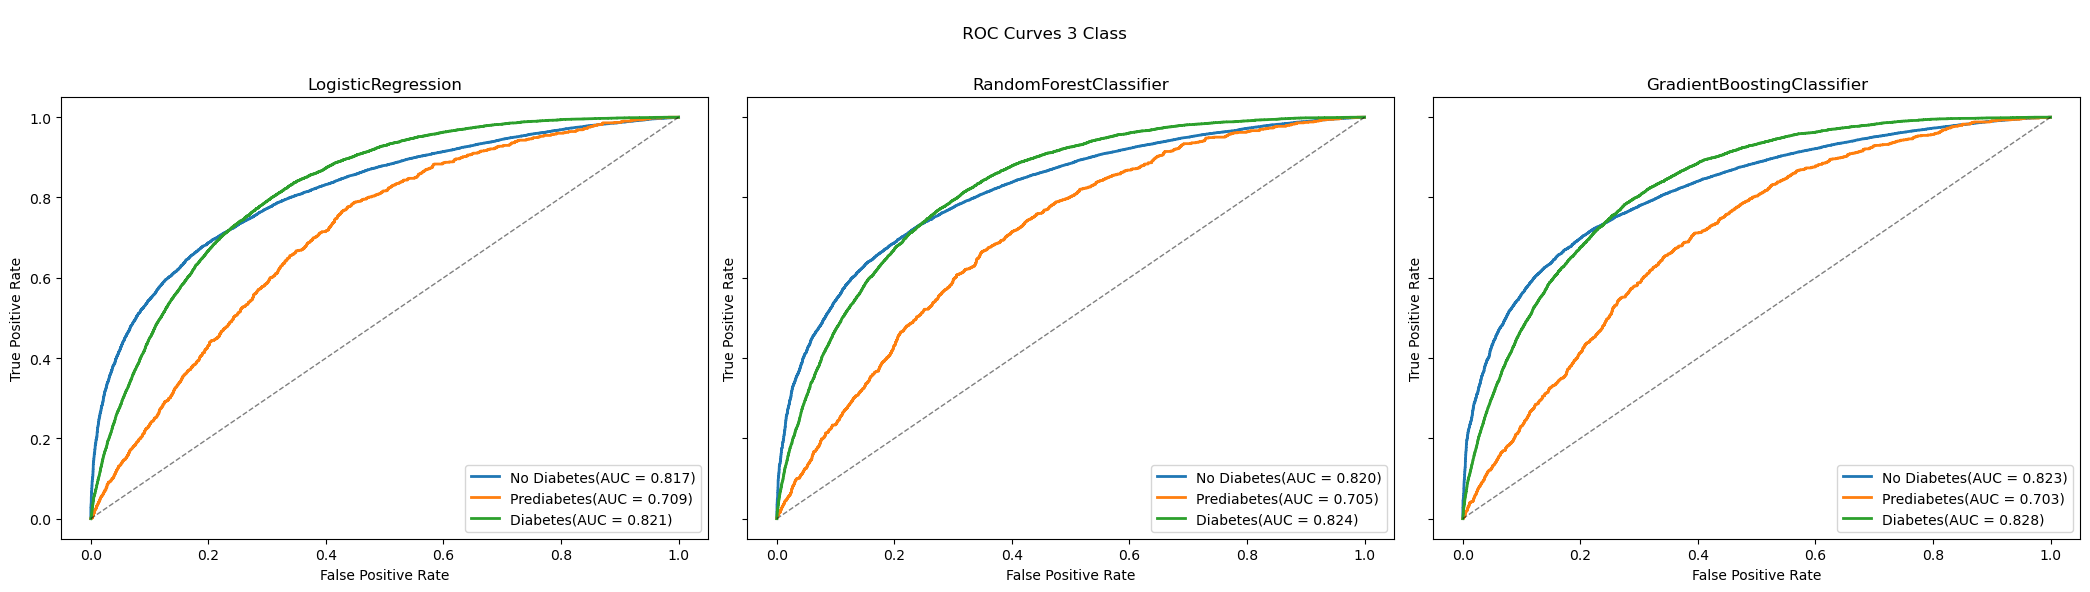

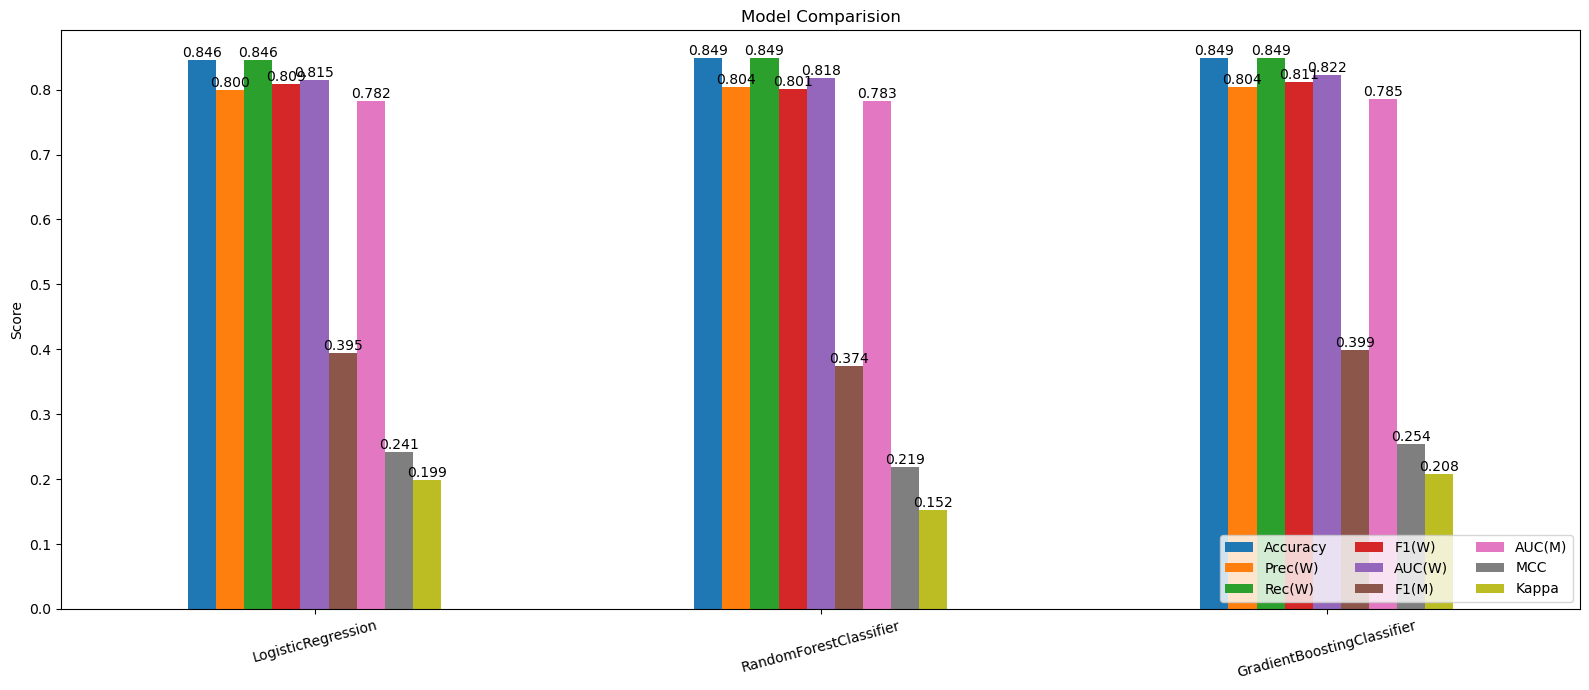


 Best model Confusion Matrix and Feature Importance 



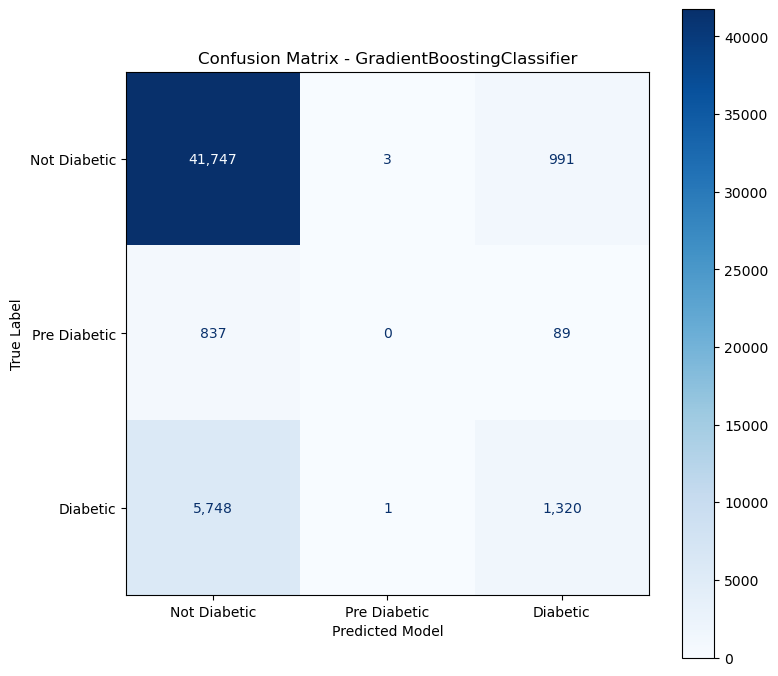

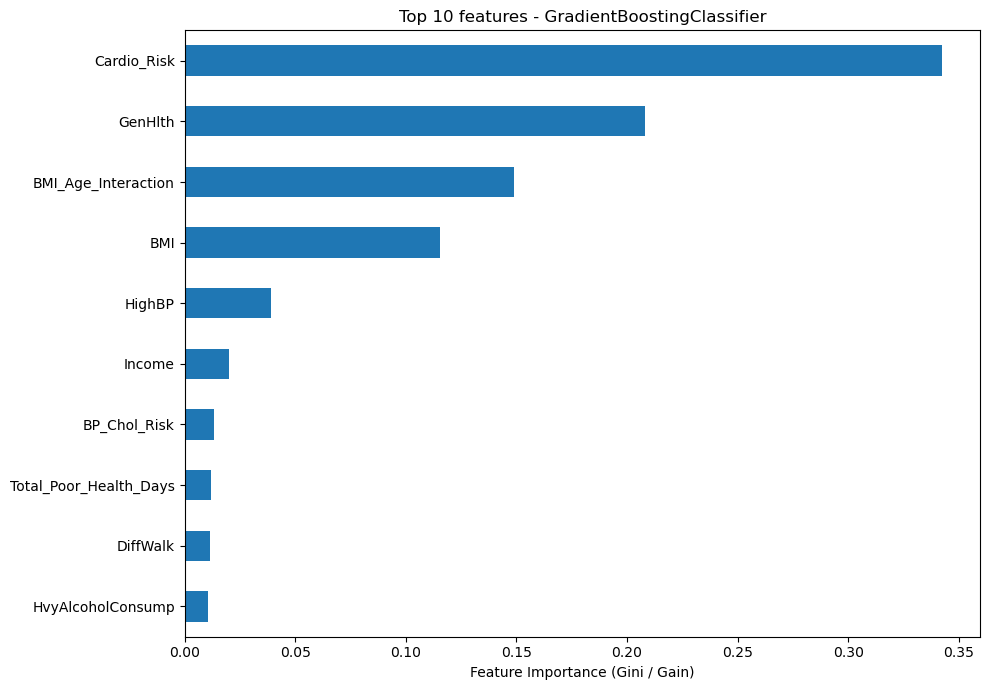

In [26]:
results, X_test, y_test, feature_cols = train_and_compare(X, y, feature_cols)

In [27]:
save_best_model(results,feature_cols)


 Best model: GradientBoostingClassifier

AUC-ROC(weighted):0.8220


('GradientBoostingClassifier',
 Pipeline(steps=[('clf',
                  GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                             random_state=42))]))

## Evaluating with SHAP

In [28]:
def evaluate_with_shap(model_path='models/best_model.pkl',
                       feature_cols_path='models/feature_cols.pkl',
                        n_explain=500):
    df=pd.read_csv("https://raw.githubusercontent.com/razibdash/Diabetes-Health-Indicators/main/diabetes_012_health_indicators_BRFSS2015.csv")
    
    pipe=joblib.load(model_path)
    feature_cols=joblib.load(feature_cols_path)
    X,y,_,_ = load_data(df)
    # Sample for SHAP
    np.random.seed(42)
    idx = np.random.choice(len(X),min(n_explain,len(X)),replace=False)
    X_sample=X.iloc[idx]
    print(f'Computing SHAP values for {len(X_sample)} samples with ({len(class_names)}) classes....')
    
    # Extract the raw clssifier and tranform the data if needed
    clf=pipe.named_steps.get('clf',pipe)
    if 'scaler' in pipe.named_steps:
        X_transformed=pipe.named_steps['scaler'].transform(X_sample)
    else:
        X_transformed=X_sample.values

    # Create SHAP Explainer
    try:
        if hasattr(clf,'feature_importances_'):
            # Used for Tree Based model (RF,GB)
            explainer=shap.TreeExplainer(clf)
        else:
        # Used for linear model (LR,LogR)
            explainer=shap.LinearExplainer(clf,X_transformed)
            shap_values = explainer.shap_values(X_tranformed)
    except Exception as e:
        print(f'Tree Explainer Doesnot support this model : {e}')
        background = shap.kmeans(X_transformed,10)
        explainer=shap.KernelExplainer(clf.predict_proba,background)
        shap_values = explainer.shap_values(X_transformed)
        
        
    # Ensure it is a list of arrays (one per class)
    if isinstance(shap_values,list):
        shap_values_list = shap_values
    elif shap_values.ndim ==3:
        # some explainer return shape
        shap_values_list = [shap_values[:,:,i] for i in range(shap_values.shape[2])]
    else:
        # For single class
        shap_values_list = [shap_values]

    # Generate per class beeswarn plot
    for i, cls_name in enumerate(class_names):
        if i>=len(shap_values_list):break
        plt.figure(figsize=(12,8))
        plt.title(f'Shap - what drives "{cls_name}" Predictions')  
        shap.summary_plot(shap_values_list[i],X_sample,feature_names=feature_cols,max_display=15)    
        #plt.tight_layout()
        #plt.show()
        
        
    if len(shap_values_list)>1:
        mean_abs_per_class = [np.abs(sv).mean(axis=0) for sv in shap_values_list]
        mean_abs_overall = np.mean(mean_abs_per_class,axis=0)
        feat_imp = pd.Series(mean_abs_overall,index=feature_cols).sort_values(ascending=True)
        plt.figure(figsize=(10,6))
        feat_imp.tail(10).plot(kind='barh',color='blue')
        plt.title('Overall Feature Importance')
        plt.xlabel('Mean')
        plt.tight_layout()
        plt.show()
    
    return 

Computing SHAP values for 500 samples with (3) classes....
Tree Explainer Doesnot support this model : GradientBoostingClassifier is only supported for binary classification right now!


C:\Users\SABYA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\SABYA\AppData\Local\Temp\ipykernel_28488\434728911.py:53: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_list[i],X_sample,feature_names=feature_cols,max_display=15)


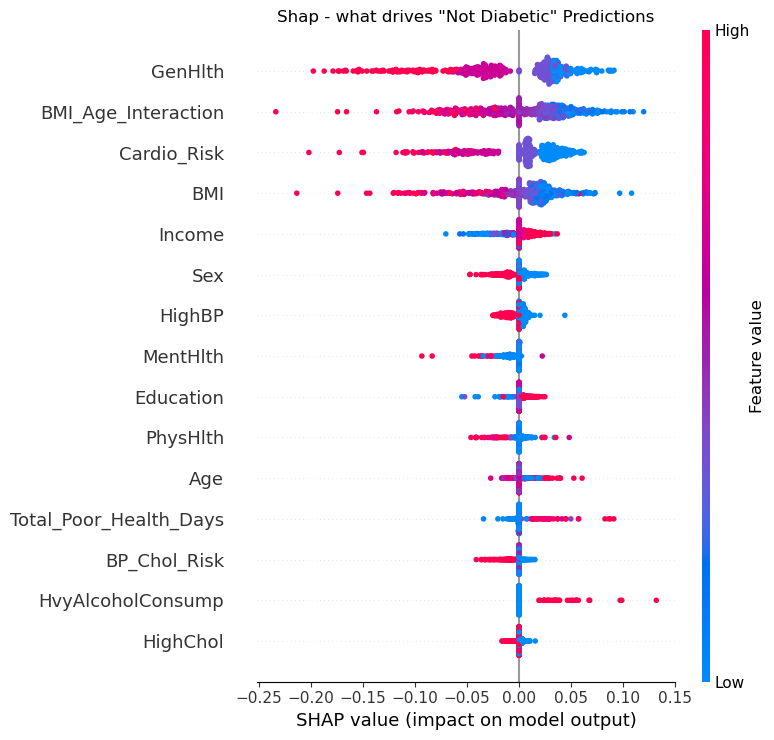

C:\Users\SABYA\AppData\Local\Temp\ipykernel_28488\434728911.py:53: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_list[i],X_sample,feature_names=feature_cols,max_display=15)


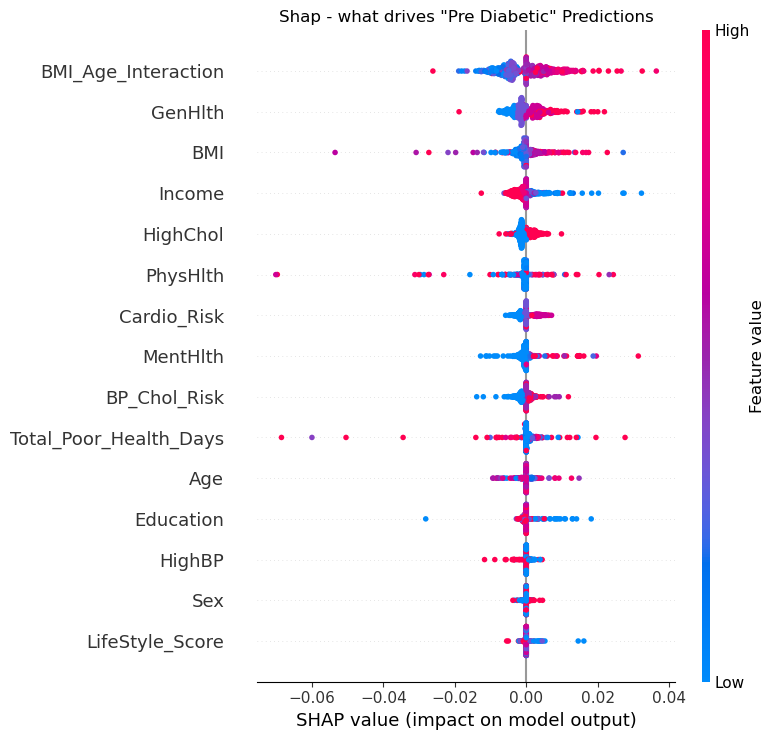

C:\Users\SABYA\AppData\Local\Temp\ipykernel_28488\434728911.py:53: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_list[i],X_sample,feature_names=feature_cols,max_display=15)


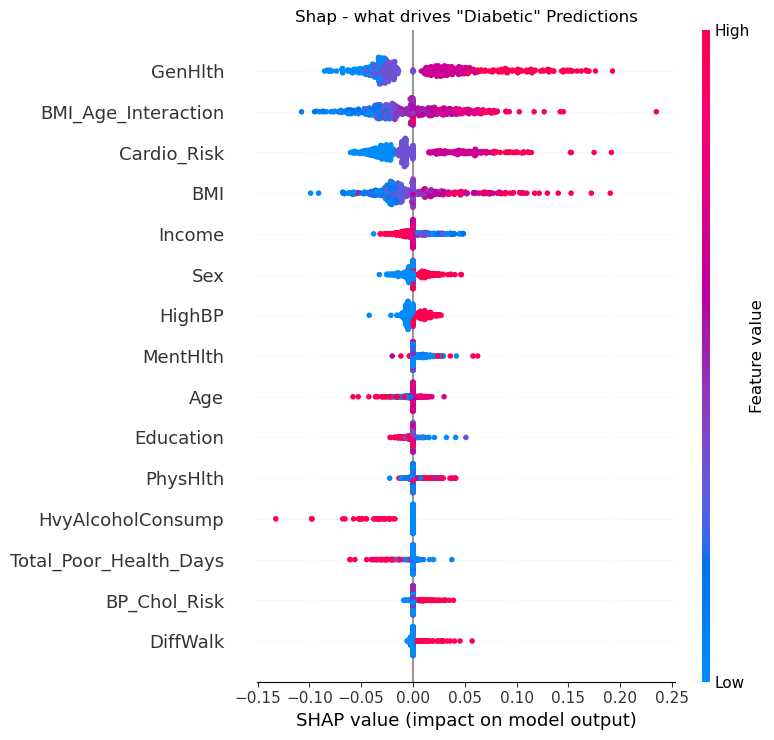

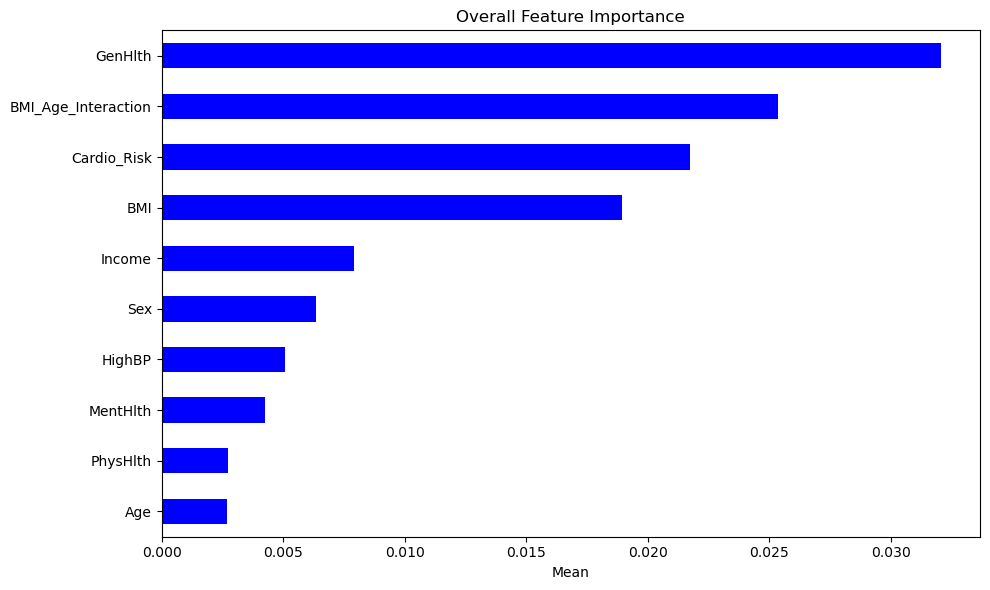

In [29]:
evaluate_with_shap()

## Streamlit App deployment

In [41]:
%%writefile diabetic_prediction_app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import os

st.set_page_config(page_title='Diabetes Risk Predictor',layout='wide',page_icon="🏥")
st.title('Diabetes Risk Assessment Tool')
st.markdown('Powered by CDC Survey Records')
st.divider()

# If not foud condition can be added. Ignored while practice
model_path = 'models/best_model.pkl'
model=joblib.load(model_path)
feature_cols=joblib.load('models/feature_cols.pkl')

col1,col2,col3 = st.columns(3)

with col1:
    st.subheader("🩺 Health condition")
    high_bp = st.selectbox('High Blood Pressure ?',['No','Yes'])
    high_chol = st.selectbox('High Cholestrol ?',['No','Yes'])
    chol_check = st.selectbox('Cholestrol Check (Last 5 years)?',['No','Yes'])
    stroke = st.selectbox('Ever had a stroke ?',['No','Yes'])
    heart_disease = st.selectbox('Heart Disease / Attack ?',['No','Yes'])
    diff_walk = st.selectbox('Difficulty Walking ?',['No','Yes'])


with col2:
    st.subheader("📊 Vitals & Lifestyle")
    bmi = st.slider("BMI",12,60,27)
    smoker = st.selectbox('Smoking Habits ?',['No','Yes'])
    phys_activity = st.selectbox('Physical Activity (Last 30 Days)?',['No','Yes'])
    fruits = st.selectbox('Eat fruits daily ?',['No','Yes'])
    veggies = st.selectbox('Eat veggies daily ?',['No','Yes'])
    heavy_alcohol = st.selectbox('Heavy alcohol consumption ?',['No','Yes'])

with col3:
    st.subheader("👤 Demographics")
    gen_health = st.selectbox("General Health", ["Excellent", "Very Good", "Good", "Fair", "Poor"])
    ment_hlth = st.slider("Poor Mental Health Days (month)", 0, 30, 0)
    phys_hlth = st.slider("Poor Physical Health Days (month)", 0, 30, 0)
    sex = st.selectbox("Sex", ["Female", "Male"])
    age_cat = st.selectbox("Age Group", [
        '18-24', '25-29', '30-34', '35-39', '40-44', '45-49',
        '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+'])
    education = st.selectbox("Education", [
        "Never attended", "Elementary", "Some high school",
        "High school graduate", "Some college", "College graduate"])
    income = st.selectbox("Income", [
        '<$10K', '$10-15K', '$15-20K', '$20-25K',
        '$25-35K', '$35-50K', '$50-75K', '$75K+'])
    healthcare = st.selectbox("Have Healthcare Coverage?", ["Yes", "No"])
    no_doc_cost = st.selectbox("Couldn't See Doctor (Cost)?", ["No", "Yes"])

st.divider()
yn = lambda s: 1 if s=="Yes" else 0
age_map = {'18-24':1,'25-29':2,'30-34':3,'35-39':4,'40-44':5,'45-49':6,'50-54':7,'55-59':8,'60-64':9,'65-69':10,'70-74':11,'75-79':12,'80+':13}
health_map = {"Excellent":1,"Very Good":2,"Good":3,"Fair":4,"Poor":5}
edu_map = {"Never attended":1,"Elementary":2,"Some high school":3,"High school graduate":4,"Some college":5,"College graduate":6}
inc_map = {'<$10K':1,'$10-15K':2,'$15-20K':3,'$20-25K':4,'$25-35K':5,'$35-50K':6,'$50-75K':7,'$75K+':8}

if st.button("🔍 Predict Diabetes Risk", type="primary", use_container_width=True):
    input_dict = {
        'HighBP': yn(high_bp), 'HighChol': yn(high_chol),
        'CholCheck': yn(chol_check), 'BMI': float(bmi),
        'Smoker': yn(smoker), 'Stroke': yn(stroke),
        'HeartDiseaseorAttack': yn(heart_disease),
        'PhysActivity': yn(phys_activity), 'Fruits': yn(fruits),
        'Veggies': yn(veggies), 'HvyAlcoholConsump': yn(heavy_alcohol),
        'AnyHealthcare': yn(healthcare), 'NoDocbcCost': yn(no_doc_cost),
        'GenHlth': health_map[gen_health],
        'MentHlth': float(ment_hlth), 'PhysHlth': float(phys_hlth),
        'DiffWalk': yn(diff_walk),
        'Sex': 1 if sex == "Male" else 0,
        'Age': age_map[age_cat],
        'Education': edu_map[education],
        'Income': inc_map[income],
    }
    input_df = pd.DataFrame([input_dict])
    # Align columns with training
    for c in feature_cols:
        if c not in input_df.columns:
            input_df[c] = 0
    input_df = input_df[feature_cols]

    try:
        probs = model.predict_proba(input_df)[0]
        prob_no = probs[0]
        prob_pre = probs[1]
        prob_diab = probs[2]
        pred_class = np.argmax(probs)
        
        st.divider()
        st.markdown("### 📋 Prediction Results")
        
        c1, c2, c3 = st.columns(3)
        with c1:
            st.metric("🟢 No Diabetes", f"{prob_no:.1%}")
        with c2:
            st.metric("🟡 Prediabetes", f"{prob_pre:.1%}")
        with c3:
            st.metric("🔴 Diabetes", f"{prob_diab:.1%}")
            
        st.markdown("---")
        
        if pred_class == 2:
            st.error(f"⚠️ **HIGH RISK (DIABETES INDICATED)** - Please consult a healthcare provider.")
        elif pred_class == 1:
            st.warning(f"⚡ **MODERATE RISK (PREDIABETES INDICATED)** - Lifestyle adjustments may be recommended.")
        else:
            st.success(f"✅ **LOW RISK (NO DIABETES INDICATED)** - Keep up the healthy habits!")
            st.subheader("📋 Key Risk Factors Detected")
            risks = []
            if yn(high_bp): risks.append("• High Blood Pressure")
            if yn(high_chol): risks.append("• High Cholesterol")
            if bmi >= 30: risks.append(f"• Obesity (BMI={bmi})")
            if age_map[age_cat] >= 9: risks.append(f"• Age 60+")
            if not yn(phys_activity): risks.append("• No Physical Activity")
            if yn(heart_disease): risks.append("• Heart Disease History")
            if health_map[gen_health] >= 4: risks.append("• Fair/Poor General Health")
            st.markdown("\n".join(risks) if risks else "No major risk factors detected.")
    except Exception as e:
        st.error(f"Error: {e}")


Writing diabetic_prediction_app.py


In [44]:
!streamlit run diabetic_prediction_app.py

^C
